# Modulo 2 - Regressione
## Notebook Esercizi - Tracce 


---

In [1]:
# ----------------------------------------------------------------
# CELLA DI SETUP - eseguire questa cella prima di tutte le altre
# ----------------------------------------------------------------

import numpy as np                 # calcolo numerico (array, operazioni matematiche)
import pandas as pd                # tabelle e dataframe
import matplotlib.pyplot as plt    # grafici

# Impostazioni globali dei grafici: dimensione, griglia leggera
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

---
## Unita 2.1 - Regressione Lineare e OLS


### Esercizio 2.1.1 - Dal modello lineare alla stima OLS

**Riferimento:** Unita 2.1 - "Il Modello Lineare", "La Funzione di Perdita: MSE",
"Stima OLS: Le Equazioni Normali"

---

**Il ragionamento**

Come nella slide "Il Modello Lineare" (esempio dell'auto usata), un modello
lineare fa una previsione combinando le feature con dei pesi: cambiando i
pesi cambia la previsione. Ma come troviamo i pesi giusti?

1. Prima proviamo a sceglierli "a occhio": quasi sicuramente l'errore
   (MSE, slide "La Funzione di Perdita: MSE") sara alto.
2. Poi calcoliamo i pesi con le **equazioni normali** (slide "Stima OLS"):
   una formula che restituisce direttamente i pesi che rendono l'MSE il
   piu basso possibile, senza bisogno di procedere per tentativi.

L'esercizio serve a toccare con mano la differenza tra "indovinare" e
"calcolare" i pesi.

---

**Dati:** superficie (mq) e prezzo (k€) di 14 appartamenti (stessa relazione
mostrata nella slide "Cos'e la Regressione?").

**Cosa fare:**
1. Genera `prezzo` con la relazione simulata fornita nel codice
2. Scegli due pesi a caso, `w` e `b`, e calcola le previsioni
   `previsione = w * superficie + b`; calcola l'MSE di questa scelta
3. Costruisci la design matrix X (colonna di 1 + superficie) e calcola i
   pesi ottimali con la formula delle equazioni normali:
   `theta = inv(X.T @ X) @ X.T @ prezzo`
4. Calcola le nuove previsioni e il nuovo MSE, confrontalo con quello del
   punto 2, e disegna entrambe le rette sullo stesso grafico

**Cosa aspettarsi:** l'MSE calcolato con OLS deve risultare sempre minore
o uguale all'MSE dei pesi scelti a caso: nessun'altra scelta di w e b può
fare meglio, su questi dati, dei pesi trovati da OLS.

MSE con pesi scelti a caso: 5270.79
Pesi OLS: intercetta=13.16, peso=2.31
MSE con pesi OLS: 31.97


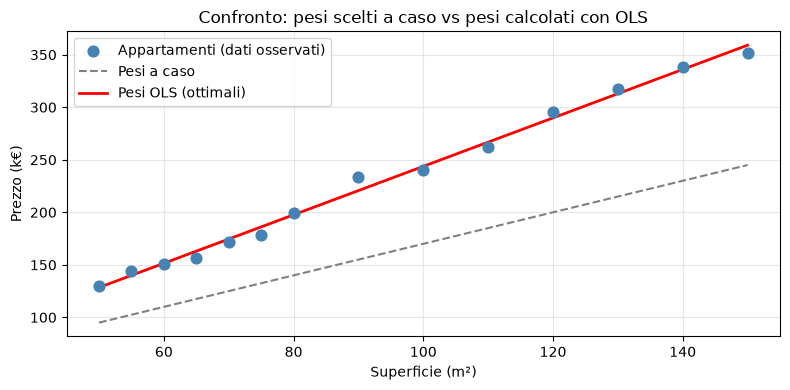

In [5]:
# ----------------------------------------------------------------
# 2.1.1 - Dal modello lineare alla stima OLS
# ----------------------------------------------------------------

import numpy as np

superficie = np.array([50, 55, 60, 65, 70, 75, 80, 90, 100, 110, 120, 130, 140, 150], dtype=float)

rng = np.random.default_rng(7)
prezzo = 2.3 * superficie + 15 + rng.normal(0, 9, size=superficie.shape)

# Passo 1:
w, b = 1.5, 20.0
previsione_a_mano = w * superficie + b

residui_a_mano = prezzo - previsione_a_mano
mse_a_mano = np.mean(residui_a_mano ** 2)
print("MSE con pesi scelti a caso: {:.2f}".format(mse_a_mano))

# Passo 2:
X = np.column_stack(([np.ones_like(superficie), superficie])) # np.ones_like(superficie) crea una lista di quattordici 1
# np.column_stack incolla questa colonna di 1 di fianco alla colonna delle superfici. Ora $X$ è una matrice pronta per i calcoli.

theta_ols = np.linalg.inv(X.T @ X) @ X.T @ prezzo
intercetta, peso = theta_ols
print("Pesi OLS: intercetta={:.2f}, peso={:.2f}".format(intercetta, peso))

previsione_ols = X @ theta_ols
mse_ols = np.mean((prezzo - previsione_ols) ** 2)
print("MSE con pesi OLS: {:.2f}".format(mse_ols))

# --- Confronto grafico ---
plt.figure()
plt.scatter(superficie, prezzo, color="steelblue", s=60, zorder=5, label="Appartamenti (dati osservati)")
plt.plot(superficie, previsione_a_mano, color="gray", linestyle="--", label="Pesi a caso")
plt.plot(superficie, previsione_ols, color="red", linewidth=2, label="Pesi OLS (ottimali)")
plt.xlabel("Superficie (m²)")
plt.ylabel("Prezzo (k€)")
plt.title("Confronto: pesi scelti a caso vs pesi calcolati con OLS")
plt.legend()
plt.tight_layout()
plt.show()

---
## Unita 2.3 - Gradient Descent

> Riferimento: slide "Perche il Gradient Descent?", "Il Gradiente: Direzione di
> Salita Massima", "Il Ruolo del Learning Rate", "Varianti del Gradient Descent"

Le equazioni normali danno una soluzione esatta in un solo calcolo, ma
diventano costose quando i dati crescono. Il Gradient Descent (come la
discesa da una collina nella nebbia, slide "Perche il Gradient Descent?")
trova la soluzione passo dopo passo, muovendosi nella direzione opposta
al gradiente.

### Esercizio 2.3.1 - Il ruolo del learning rate

**Riferimento:** Unita 2.3 - "Il Gradiente: Direzione di Salita Massima",
"Il Ruolo del Learning Rate"

---

**Il ragionamento**

La slide "Il Gradiente" spiega che il gradiente punta nella direzione in
cui la loss cresce di piu: per minimizzarla ci muoviamo nella direzione
**opposta**. La slide "Il Ruolo del Learning Rate" mostra tre scenari:
passo troppo piccolo (si converge, ma lentamente), passo ottimale
(si converge rapidamente e in modo stabile), passo troppo grande (la
loss oscilla o addirittura peggiora). In questo esercizio riproduciamo
questi tre scenari con i nostri dati.

---

Riutilizza `superficie` e `prezzo` dell'Unita 2.1. Per stabilita numerica,
standardizza prima la superficie: `x = (superficie - media) / dev_std`.

**Cosa fare:**
1. Implementa `gradient_descent(x, y, lr, n_iter)`: ad ogni iterazione
   calcola la previsione, il gradiente della loss (formule nei commenti
   della soluzione), e aggiorna i pesi muovendosi nella direzione
   **opposta** al gradiente
2. Esegui la funzione con tre learning rate: uno piccolo (0.01), uno
   adeguato (0.1), uno troppo grande (1.5)
3. Disegna un grafico con la loss ad ogni iterazione, una linea per
   ciascun learning rate (usa una scala logaritmica sull'asse y)

In [ ]:
# ----------------------------------------------------------------
# 2.3.1 - Il ruolo del learning rate
# ----------------------------------------------------------------

x = (superficie - superficie.mean()) / superficie.std()
y = prezzo.copy()
n = len(x)

def gradient_descent(x, y, lr, n_iter):
    w, b = 0.0, 0.0
    losses = []
    # TODO: ad ogni iterazione calcola previsione, errore, salva la loss (MSE)
    # TODO: calcola grad_w e grad_b (gradiente della loss) e aggiorna w, b
    #       muovendoti nella direzione OPPOSTA al gradiente
    return w, b, losses

# TODO: esegui gradient_descent con lr = 0.01, 0.1, 1.5 (30 iterazioni)
#       e disegna un grafico con le tre curve di loss (scala log sull'asse y)

---
## Unita 2.4 - Regolarizzazione

> Riferimento: slide "Il Problema dell'Overfitting in Regressione", "Ridge
> Regression", "Lasso Regression", "Elastic Net", "Scegliere la penalita"

Con molte feature (o feature correlate tra loro), OLS puo produrre pesi
enormi e instabili: il modello segue il training set quasi alla
perfezione ma generalizza male. Ridge, Lasso ed Elastic Net aggiungono
una penalita alla loss per tenere i pesi sotto controllo.

### Esercizio 2.4.1 - Overfitting: OLS vs Ridge vs Lasso vs Elastic Net

**Riferimento:** Unita 2.4 - "Il Problema dell'Overfitting in Regressione",
"Ridge Regression", "Lasso Regression", "Elastic Net"

---

**Il ragionamento**

La slide "Il Problema dell'Overfitting" mostra che con molte feature OLS
puo produrre pesi molto grandi. La causa tipica e' avere feature che
raccontano quasi la stessa informazione (**multicollinearita**): OLS non
sa a quale delle due "dare credito" e puo assegnare pesi enormi e di
segno opposto. Ridge (slide "Ridge Regression") riduce tutti i pesi ma
raramente li azzera; Lasso (slide "Lasso Regression") puo azzerarli
del tutto, selezionando le feature; Elastic Net (slide "Elastic Net")
sta nel mezzo. In questo esercizio riproduciamo il problema e confrontiamo
le tre soluzioni.

---

**Dati:** dataset simulato con 30 osservazioni e 6 feature, di cui le
prime due sono costruite per essere fortemente correlate tra loro.

**Cosa fare:**
1. Genera il dataset con il codice fornito (`X_reg`, `y_reg`)
2. Allena `LinearRegression()`, `Ridge(alpha=1.0)`, `Lasso(alpha=0.1)` e
   `ElasticNet(alpha=0.1, l1_ratio=0.5)` sugli stessi dati
3. Stampa a confronto i pesi dei quattro modelli
4. Conta quanti pesi sono esattamente zero per Ridge, Lasso ed Elastic Net

In [ ]:
# ----------------------------------------------------------------
# 2.4.1 - Overfitting: OLS vs Ridge vs Lasso vs Elastic Net
# ----------------------------------------------------------------

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

rng = np.random.default_rng(3)
n_oss, n_feat = 30, 6
X_reg = rng.normal(size=(n_oss, n_feat))
X_reg[:, 1] = X_reg[:, 0] + rng.normal(0, 0.05, n_oss)

vero_beta = np.array([3, -2, 0, 1.5, 0, 0.8])
y_reg = X_reg @ vero_beta + rng.normal(0, 1, n_oss)

# TODO: allena LinearRegression(), Ridge(alpha=1.0), Lasso(alpha=0.1),
#       ElasticNet(alpha=0.1, l1_ratio=0.5) su X_reg, y_reg

# TODO: stampa a confronto vero_beta e i pesi (coef_) dei quattro modelli

# TODO: per Ridge, Lasso, ElasticNet conta con np.isclose(coef_, 0) quanti
#       pesi sono esattamente zero

### Esercizio 2.4.2 - Scegliere la penalita con la cross-validation

**Riferimento:** Unita 2.4 - "Ridge vs Lasso: Interpretazione Geometrica",
"Scegliere la penalita"

---

**Il ragionamento**

La slide "Ridge vs Lasso: Interpretazione Geometrica" mostra perche Lasso
puo azzerare i pesi (il rombo della penalita L1 ha vertici sugli assi) e
Ridge no (il cerchio della penalita L2 non ha spigoli). La slide
"Scegliere la penalita" spiega poi come scegliere λ: non a caso, ma
provando piu valori con la cross-validation e tenendo quello con errore
di validazione piu basso. In questo esercizio visualizziamo l'effetto di
λ sui pesi Ridge e lasciamo che sia la cross-validation a scegliere il
valore migliore.

---

Riutilizza `X_reg` e `y_reg` dell'esercizio 2.4.1.

**Cosa fare:**
1. Definisci una griglia di valori di λ: `np.logspace(-2, 2, 20)`
2. Per ciascun valore, allena `Ridge(alpha=lam)` e salva i pesi ottenuti
3. Disegna il percorso dei pesi al variare di λ (asse x in scala
   logaritmica): una linea per ciascuna delle 6 feature
4. Usa `RidgeCV(alphas=griglia, cv=5)` per trovare automaticamente il
   miglior λ tramite cross-validation, e stampalo

In [ ]:
# ----------------------------------------------------------------
# 2.4.2 - Scegliere la penalita con la cross-validation
# ----------------------------------------------------------------

from sklearn.linear_model import Ridge, RidgeCV

griglia_lambda = np.logspace(-2, 2, 20)

# TODO: per ogni lambda nella griglia, allena Ridge(alpha=lambda) su
#       X_reg, y_reg e salva i pesi ottenuti in una lista

# TODO: disegna il percorso dei pesi (una linea per feature) al variare
#       di lambda, con l'asse x in scala logaritmica

# TODO: usa RidgeCV(alphas=griglia_lambda, cv=5) per trovare il lambda
#       migliore e stampalo (attributo .alpha_)

---
## Unita 2.5 - Feature Engineering

> Riferimento: slide "Oltre la Retta: Regressione Polinomiale", "Bias-Variance
> Tradeoff", "Pipeline Completa", "Valutare la Regressione", "Regressione
> Multipla: Feature Correlate", "Caso Studio Completo"

Chiudiamo il modulo con la regressione polinomiale, il tradeoff
bias-varianza, e un caso studio completo che mette insieme pipeline,
feature correlate e metriche di valutazione.

### Esercizio 2.5.1 - Regressione polinomiale e bias-varianza

**Riferimento:** Unita 2.5 - "Oltre la Retta: Regressione Polinomiale",
"Bias-Variance Tradeoff", "Grado del Polinomio e Bias-Variance"

---

**Il ragionamento**

La slide "Oltre la Retta" mostra che aggiungendo feature come x al
quadrato, x al cubo, ecc. il modello resta lineare nei pesi ma puo
disegnare curve. La slide "Grado del Polinomio e Bias-Variance" mostra
pero che il grado va scelto con attenzione: troppo basso e il modello
non cattura la curva (**underfitting**, alto bias); troppo alto e il
modello insegue anche il rumore (**overfitting**, alta varianza). Il
modo corretto per scegliere il grado e' confrontare l'errore su dati
**mai usati in addestramento** (test set), non l'errore di training.

---

**Dati:** relazione quadratica con rumore, `x` in [-3, 3].

**Cosa fare:**
1. Genera il dataset e dividilo in training e test con `train_test_split`
   (`test_size=0.3`)
2. Per gradi da 1 a 10, trasforma la feature con `PolynomialFeatures`,
   allena una `LinearRegression`, calcola l'MSE su training e su test
3. Disegna un grafico con le due curve di errore (training e test) al
   variare del grado, e individua il grado con errore di test minimo

In [ ]:
# ----------------------------------------------------------------
# 2.5.1 - Regressione polinomiale e bias-varianza
# ----------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(11)
x_poly = np.linspace(-3, 3, 60)
y_poly = 0.5 * x_poly ** 2 - x_poly + 2 + rng.normal(0, 1.3, size=x_poly.shape)
X_poly = x_poly.reshape(-1, 1)

# TODO: dividi X_poly, y_poly in train/test con test_size=0.3, random_state=42

gradi = range(1, 11)

# TODO: per ogni grado, trasforma con PolynomialFeatures (fit_transform sul
#       train, transform sul test), allena una LinearRegression, calcola
#       l'MSE su train e su test, salva entrambi

# TODO: trova il grado con errore di test minimo e disegna il grafico
#       errore di training / errore di test al variare del grado

### Esercizio 2.5.2 - Caso studio: pipeline, feature correlate e metriche

**Riferimento:** Unita 2.5 - "Pipeline Completa", "Valutare la Regressione:
Recap delle Metriche", "Regressione Multipla: Feature Correlate",
"Caso Studio Completo: Previsione Prezzi Immobiliari"

---

**Il ragionamento**

Questo esercizio mette insieme gli ultimi concetti della slide "Caso
Studio Completo": prima si controllano le correlazioni tra le feature
(slide "Regressione Multipla: Feature Correlate" - feature quasi
duplicate rendono instabili i pesi), poi si costruisce una pipeline che
applica sempre nello stesso ordine standardizzazione e modello (slide
"Pipeline Completa"), infine si valuta il risultato con piu di una
metrica (slide "Valutare la Regressione": MAE, RMSE, R²), perche ognuna
racconta un aspetto diverso dell'errore.

---

**Dati:** dataset simulato di 150 appartamenti con tre feature
(superficie, numero di vani, eta dell'edificio). Nota: superficie e vani
sono costruite per essere correlate, per riprodurre una situazione
realistica.

**Cosa fare:**
1. Genera il dataset con il codice fornito e costruiscilo come DataFrame
2. Calcola la matrice di correlazione (`df.corr()`) e individua la coppia
   di feature piu correlata
3. Dividi in train/test, poi costruisci una `Pipeline` con due passi:
   `StandardScaler` (standardizzazione) e `Ridge(alpha=10)`
4. Calcola sul test set le tre metriche R², MAE, RMSE

In [ ]:
# ----------------------------------------------------------------
# 2.5.2 - Caso studio: pipeline, feature correlate e metriche
# ----------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

rng = np.random.default_rng(99)
n_case = 150
superficie_c = rng.uniform(40, 180, n_case)
vani_c = np.round(superficie_c / 28 + rng.normal(0, 0.4, n_case)).clip(1, 7)
eta_edificio = rng.uniform(0, 50, n_case)

prezzo_casa = (
    1600 * superficie_c
    + 6000 * vani_c
    - 300 * eta_edificio
    + rng.normal(0, 12000, n_case)
)

# TODO: costruisci df_case come DataFrame pandas con le 4 colonne sopra

# TODO: stampa df_case.corr().round(2) e individua la coppia di feature
#       piu correlata

# TODO: dividi in train/test (test_size=0.2, random_state=42)

# TODO: costruisci una Pipeline con "scaler" (StandardScaler) e
#       "ridge" (Ridge(alpha=10)), allenala sul training set

# TODO: calcola le previsioni sul test set e stampa R², MAE, RMSE